# 05 - Segmentation Modelling

Applying K-Means clustering to the engineered feature matrix
to discover natural customer segments.

The optimal number of clusters is determined using the
elbow method and silhouette score before fitting the
final model.

In [1]:
# Set up
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from settings import PATHS, apply_pandas_settings, apply_plot_settings

apply_pandas_settings()
apply_plot_settings()

In [2]:
# Load feature matrix

features = pd.read_csv(PATHS['features'])

In [3]:
features.head()

,customer_id,frequency,monetary,recency,pre_pivot_frequency,pivot_ratio,product_diversity,loan_taken,loan_defaulted
0,CUS00001,11,351800.00,6,10,1.00,4,0,0
1,CUS00002,1,90250.00,27,10,0.09,1,1,0
2,CUS00003,0,0.00,184,6,0.00,0,1,0
3,CUS00004,15,1122650.00,13,9,1.50,5,0,0
4,CUS00005,0,0.00,184,3,0.00,0,1,1


## Exploratory Visualisation 

3D scatter plot of the three most behaviourally meaningful
features to get an intuitive sense of customer groupings
before clustering.

In [4]:
features_3d = features[['frequency', 'monetary', 'recency']].copy()

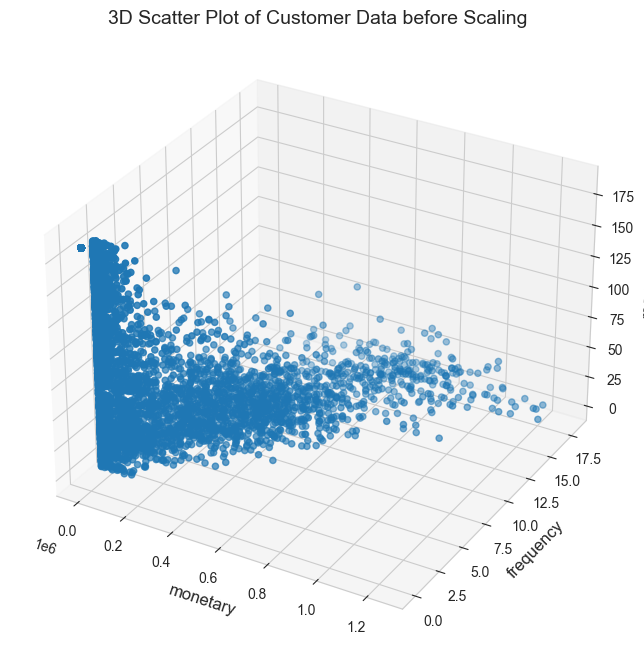

In [5]:
fig = plt.figure(figsize = (8, 8))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(features_3d['monetary'], features_3d['frequency'], features_3d['recency'])

ax.set_xlabel('monetary')
ax.set_ylabel('frequency')
ax.set_zlabel('recency')

ax.set_title('3D Scatter Plot of Customer Data before Scaling')
plt.show()

## Step 1 - Feature Scaling

K-Means uses Euclidean distance to measure similarity between
customers. Features with large value ranges - particularly
monetary (with very high values) — would dominate distance calculations
without scaling.

StandardScaler transforms each feature to have mean=0 and
standard deviation=1, ensuring all features contribute equally.

In [6]:
# Scale features

input = features.drop(columns = ['customer_id'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(input)

scaled_data = pd.DataFrame(scaled_data, columns = input.columns)

In [7]:
scaled_data.head()

,frequency,monetary,recency,pre_pivot_frequency,pivot_ratio,product_diversity,loan_taken,loan_defaulted
0,1.64,1.06,-1.17,1.02,0.93,1.37,-1.13,-0.62
1,-0.56,-0.23,-0.88,1.02,-0.63,-0.43,0.89,-0.62
2,-0.78,-0.67,1.24,-0.08,-0.78,-1.03,0.89,-0.62
3,2.52,4.87,-1.07,0.75,1.79,1.98,-1.13,-0.62
4,-0.78,-0.67,1.24,-0.91,-0.78,-1.03,0.89,1.61


In [8]:
print(f"Scaled feature matrix shape: {scaled_data.shape}")
print(f"\nScaled feature summary:")
display(scaled_data.describe().round(2))

Scaled feature matrix shape: (5000, 8)

Scaled feature summary:


,frequency,monetary,recency,pre_pivot_frequency,pivot_ratio,product_diversity,loan_taken,loan_defaulted
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.78,-0.67,-1.24,-1.46,-0.78,-1.03,-1.13,-0.62
25%,-0.78,-0.67,-0.99,-0.91,-0.78,-1.03,-1.13,-0.62
50%,-0.56,-0.49,-0.25,-0.08,-0.35,-0.43,0.89,-0.62
75%,0.54,0.35,1.24,0.75,0.36,0.77,0.89,1.61
max,3.19,5.51,1.24,2.41,5.38,2.58,0.89,1.61


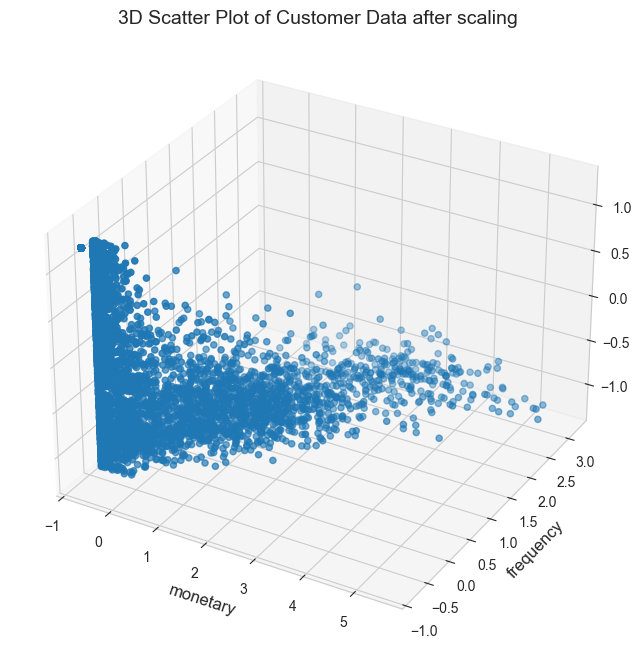

In [9]:
fig = plt.figure(figsize = (8, 8))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(scaled_data['monetary'], scaled_data['frequency'], scaled_data['recency'])

ax.set_xlabel('monetary')
ax.set_ylabel('frequency')
ax.set_zlabel('recency')

ax.set_title('3D Scatter Plot of Customer Data after scaling')
plt.show()

## Step 2 - Optimal Number of Clusters (K)

Two methods used together to determine K:
- **Elbow method** - plots inertia (within-cluster sum of squares)
  against K. The optimal K is where the curve bends - adding more
  clusters beyond this point gives diminishing returns
- **Silhouette score** - measures how well each customer fits its
  assigned cluster vs neighbouring clusters. Higher is better (max=1)

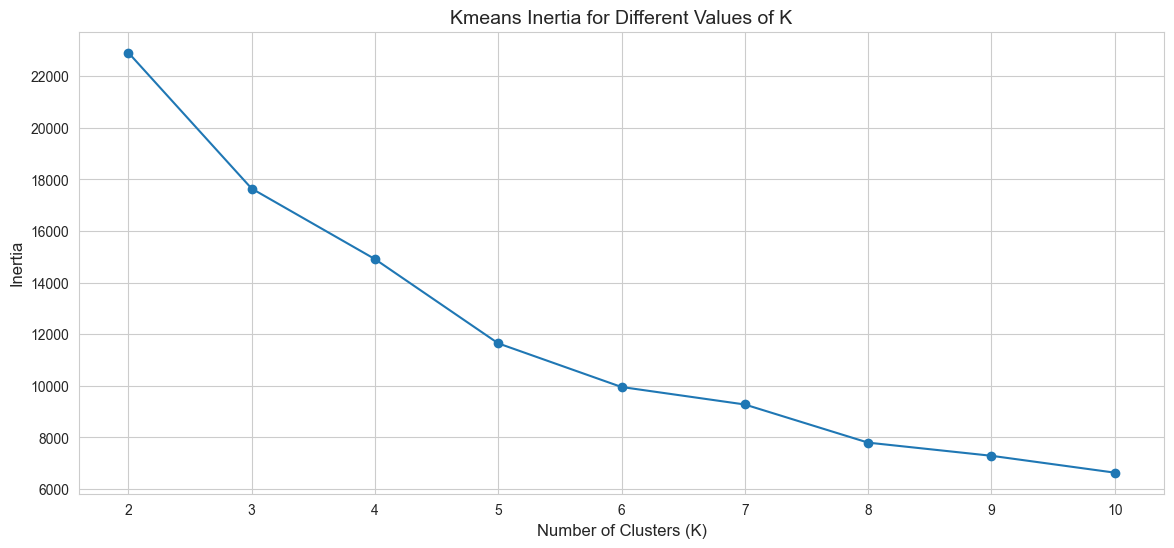

In [10]:
# Determine optimal K using the Elbow Method

max_k = 10

inertia = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, max_iter = 1000)
    kmeans.fit_predict(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize = (14,6))

plt.plot(k_values, inertia, marker = 'o')
plt.title('Kmeans Inertia for Different Values of K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.show()


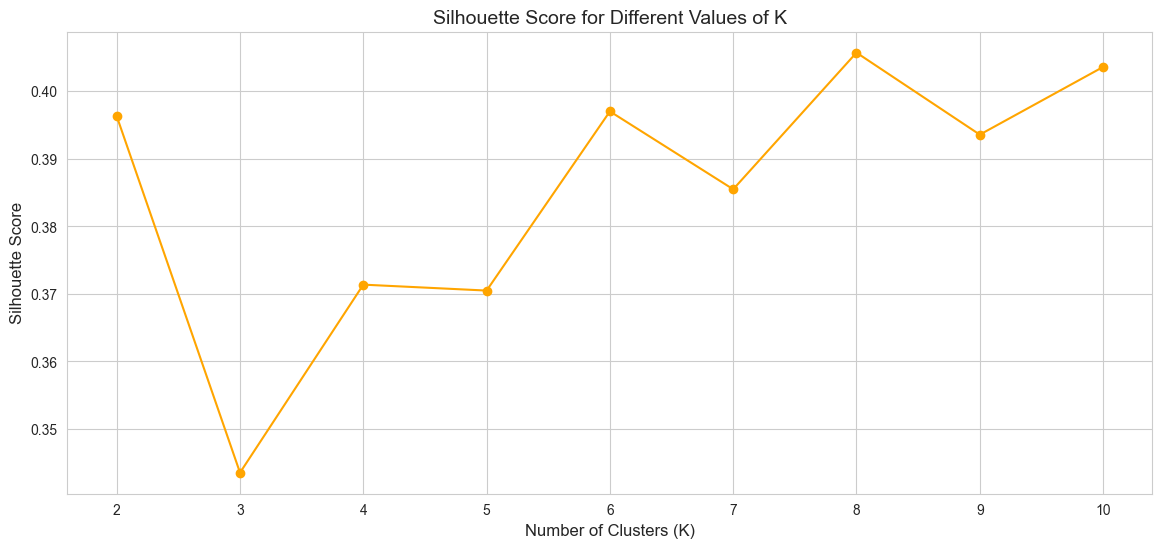

In [11]:
# Confirm optimal K using the Silhouette Score

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(n_clusters = k, random_state = 42, max_iter = 1000)

    cluster_labels = kmeans.fit_predict(scaled_data)

    sil_score = silhouette_score(scaled_data, cluster_labels)

    silhouette_scores.append(sil_score)


plt.figure(figsize = (14,6))

plt.plot(k_values, silhouette_scores, marker = 'o', color = 'orange')
plt.title('Silhouette Score for Different Values of K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()


## Step 2 - Optimal K Decision

| Method | Suggested K | Score |
|---|---|---|
| Elbow method | 5 | Inertia bend at K=5 |
| Silhouette score | 8 | Score = 0.415 |

**Decision: K=5**

The elbow method clearly suggests K=5. While the silhouette
score peaks at K=8, this would produce too many segments for
meaningful business action in a customer base of 5,000.

K=5 produces a silhouette score of 0.370 — acceptable cluster
separation actionable for the product
and growth teams.

In [12]:
# Fit KMeans model at K=5

kmeans = KMeans(n_clusters = 5, random_state = 42, max_iter = 1000)

cluster_labels = kmeans.fit_predict(scaled_data)

cluster_labels

array([4, 3, 3, ..., 1, 4, 1], shape=(5000,), dtype=int32)

In [13]:
features['clusters'] = cluster_labels

features.head()

,customer_id,frequency,monetary,recency,pre_pivot_frequency,pivot_ratio,product_diversity,loan_taken,loan_defaulted,clusters
0,CUS00001,11,351800.00,6,10,1.00,4,0,0,4
1,CUS00002,1,90250.00,27,10,0.09,1,1,0,3
2,CUS00003,0,0.00,184,6,0.00,0,1,0,3
3,CUS00004,15,1122650.00,13,9,1.50,5,0,0,0
4,CUS00005,0,0.00,184,3,0.00,0,1,1,1


In [14]:
# Save the segments

features.to_csv(PATHS['segments'], index = False)